<a href="https://colab.research.google.com/github/0906Bao/MedicalPPE_yolo/blob/main/CNN_firedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="P04I1MNoqGm4SfrEFUld")
project = rf.workspace("hois-workspace-opsbb").project("fire-detection-gj7u6-r1imy")
dataset = project.version(1).download("folder")

loading Roboflow workspace...
loading Roboflow project...


In [48]:
!pip install tensorflow
!pip install matplotlib
!pip install keras
!pip install seaborn

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [50]:
train_path = dataset.location + "/train"
valid_path = dataset.location + "/valid"
test_path = dataset.location + "/test"

In [51]:


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2236 images belonging to 2 classes.
Found 641 images belonging to 2 classes.


In [52]:
print(train_generator.class_indices)

{'fire': 0, 'non_fire': 1}


In [53]:

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(2, activation='softmax')
])

In [54]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
class_weight = {
    0: 2.5,
    1: 1.0
}

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    class_weight=class_weight
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 542ms/step - accuracy: 0.7674 - loss: 0.7257 - val_accuracy: 0.8518 - val_loss: 0.3349
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 332ms/step - accuracy: 0.8247 - loss: 0.5414 - val_accuracy: 0.8955 - val_loss: 0.3067
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.8797 - loss: 0.4217 - val_accuracy: 0.9033 - val_loss: 0.2900
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 285ms/step - accuracy: 0.8873 - loss: 0.3768 - val_accuracy: 0.9204 - val_loss: 0.2446
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 304ms/step - accuracy: 0.8940 - loss: 0.3726 - val_accuracy: 0.9454 - val_loss: 0.1850
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.8953 - loss: 0.3438 - val_accuracy: 0.9267 - val_loss: 0.2037
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 286ms/step - accuracy: 0.9106 - loss: 0.2932 - val_accuracy: 0.9407 - val_loss: 0.1684
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.9325 - loss: 0.2527 - val_accu

In [56]:
valid_generator.reset()

y_pred = model.predict(valid_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = valid_generator.classes

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step


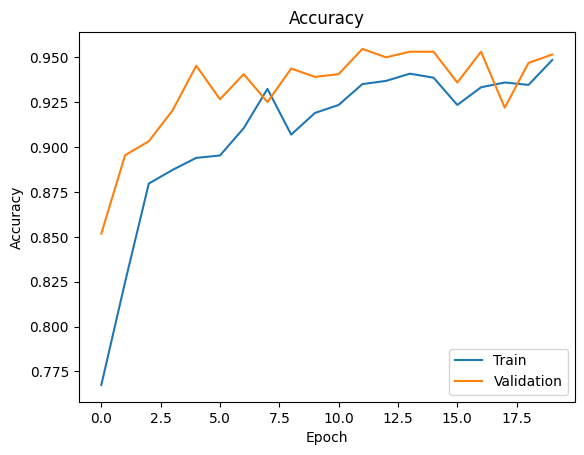

In [57]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

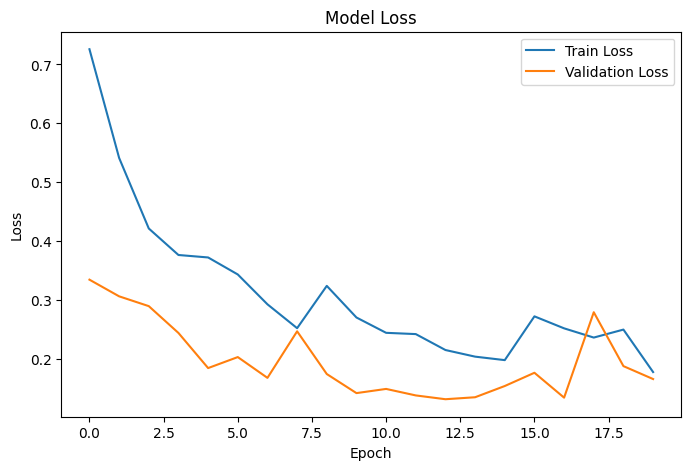

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [59]:
valid_generator.reset()

y_pred = model.predict(valid_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = valid_generator.classes

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step


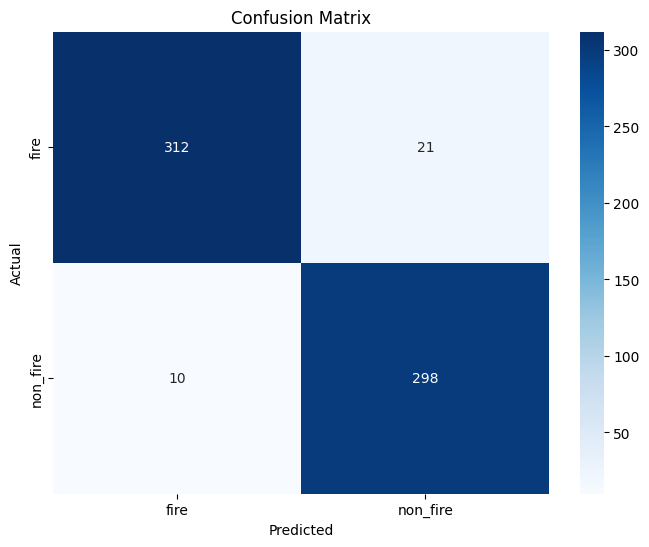

In [60]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = list(valid_generator.class_indices.keys())

valid_generator.reset()

y_pred = model.predict(valid_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = valid_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=list(valid_generator.class_indices.keys())
    )
)

              precision    recall  f1-score   support

        fire       0.97      0.94      0.95       333
    non_fire       0.93      0.97      0.95       308

    accuracy                           0.95       641
   macro avg       0.95      0.95      0.95       641
weighted avg       0.95      0.95      0.95       641



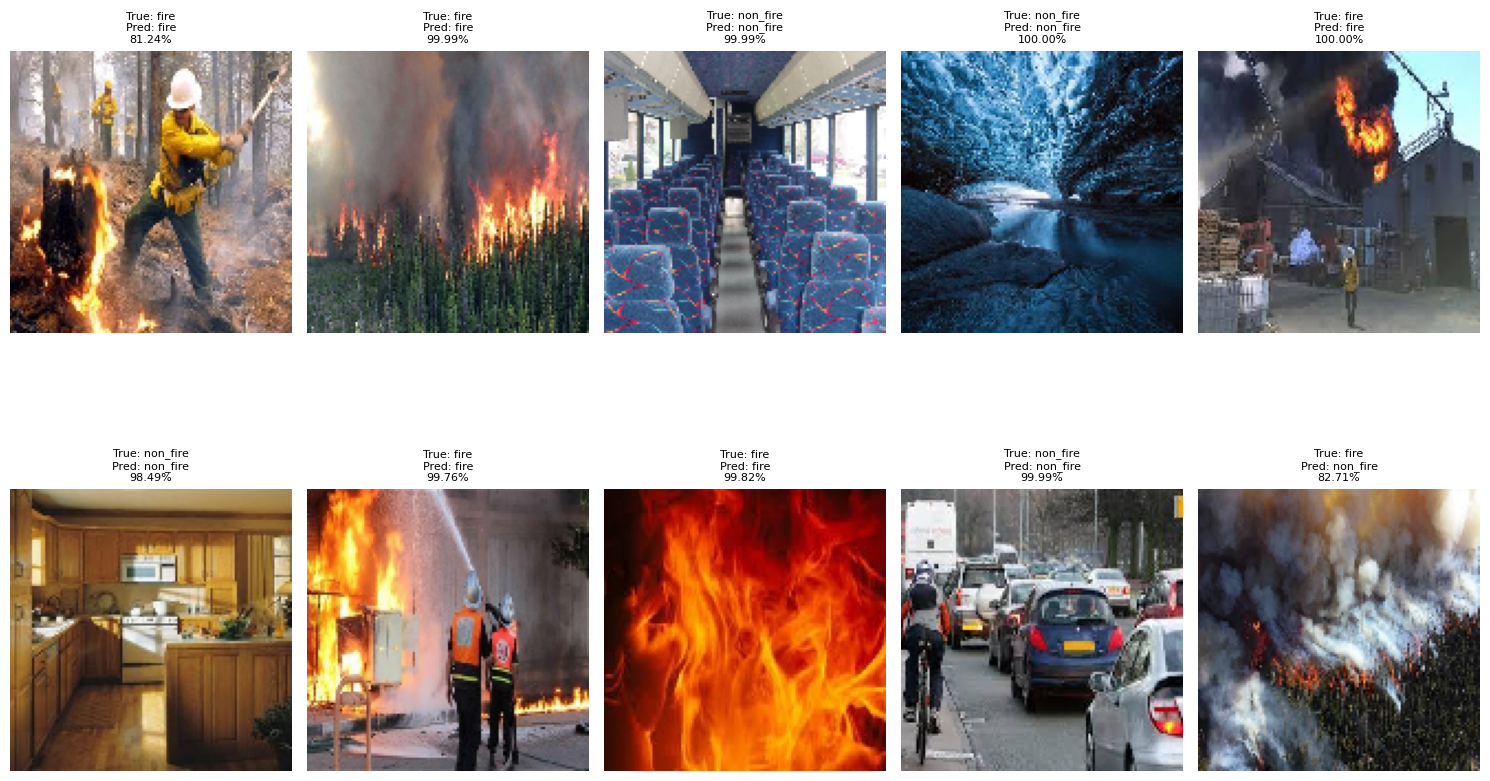

In [62]:
class_names = list(valid_generator.class_indices.keys())

filepaths = valid_generator.filepaths
true_labels = valid_generator.classes

indices = np.random.choice(len(filepaths), 10, replace=False)

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):

    img_path = filepaths[idx]

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_input, verbose=0)

    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    actual_class = true_labels[idx]

    plt.subplot(2, 5, i+1)
    plt.imshow(img)

    plt.title(
        f"True: {class_names[actual_class]}\n"
        f"Pred: {class_names[pred_class]}\n"
        f"{confidence:.2%}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

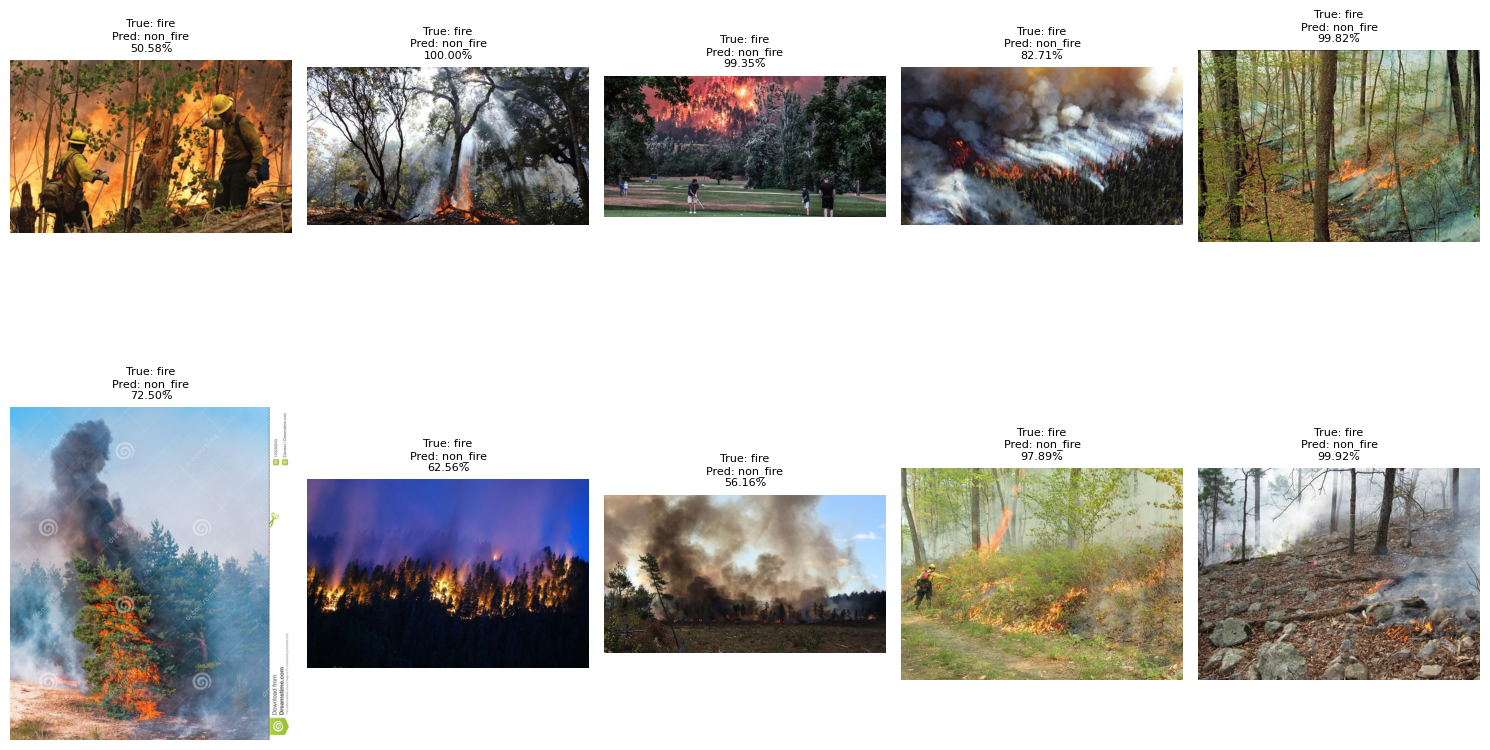

In [63]:
class_names = list(valid_generator.class_indices.keys())

wrong_images = []

for idx in range(len(valid_generator.filepaths)):

    img_path = valid_generator.filepaths[idx]

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_input, verbose=0)

    pred_class = np.argmax(pred)
    true_class = valid_generator.classes[idx]

    if pred_class != true_class:
        wrong_images.append(
            (img_path, true_class, pred_class, np.max(pred))
        )

plt.figure(figsize=(15,10))

for i, (img_path, true_class, pred_class, conf) in enumerate(wrong_images[:10]):

    img = image.load_img(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)

    plt.title(
        f"True: {class_names[true_class]}\n"
        f"Pred: {class_names[pred_class]}\n"
        f"{conf:.2%}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
pred = model.predict(img_input, verbose=0)[0]

for cls, p in zip(class_names, pred):
    print(f"{cls}: {p:.4f}")

fire: 0.0000
non_fire: 1.0000


In [68]:
model.save("fire_model.h5")